In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = fetch_california_housing(as_frame=True)
df = data.frame.sample(n=5000, random_state=42)

X = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)

result = pd.DataFrame({
    "Модель": ["LinearRegression"],
    "Ознака": ["MedInc"],
    "R²": [r2]
})

display(result)


,Модель,Ознака,R²
0,LinearRegression,MedInc,0.496119


In [5]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = fetch_california_housing(as_frame=True)
df = data.frame.sample(n=5000, random_state=42)

models_info = [
    ["MedInc", ["MedInc"]],
    ["MedInc, AveRooms", ["MedInc", "AveRooms"]]
]

results = []

for feature_name, features in models_info:
    X = df[features]
    y = df["MedHouseVal"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    r2 = model.score(X_test, y_test)

    results.append(["LinearRegression", feature_name, r2])

result = pd.DataFrame(results, columns=["Модель", "Ознаки", "R²"])
display(result)

,Модель,Ознаки,R²
0,LinearRegression,MedInc,0.496119
1,LinearRegression,"MedInc, AveRooms",0.503710


In [6]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
df = data.frame.sample(n=5000, random_state=42)

X = df[["MedInc", "AveRooms"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Метрика": ["MAE", "MSE", "RMSE", "R²"],
    "Значення": [mae, mse, rmse, r2]
})

display(metrics)

,Метрика,Значення
0,MAE,0.613654
1,MSE,0.670310
2,RMSE,0.818724
3,R²,0.503710


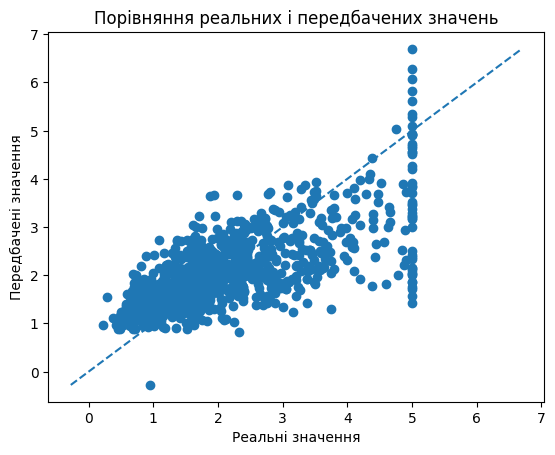

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = fetch_california_housing(as_frame=True)
df = data.frame.sample(n=5000, random_state=42)

X = df[["MedInc", "AveRooms"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Реальні значення")
plt.ylabel("Передбачені значення")
plt.title("Порівняння реальних і передбачених значень")

plt.savefig("real_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()